In [1]:
from main import McKeanVlasovSolver
from fourier_utils import FourierUtils
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from matplotlib.colors import LinearSegmentedColormap

from scipy.special import beta
from scipy.special import iv as bessel
from scipy.optimize import brentq, fixed_point
from scipy.linalg import eig, eigh
from scipy.linalg import cholesky, solve
from scipy.sparse.linalg import eigsh, eigs
from scipy.integrate import quad
from tqdm import tqdm

import scienceplots
plt.style.use('science')

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
def mu_0(x):
    alpha_param = 2.0
    beta_param = 2.0
    Z = (2 * np.pi)**(alpha_param + beta_param - 1) * beta(alpha_param, beta_param)
    return (x**(alpha_param - 1) * (2 * np.pi - x)**(beta_param - 1)) / Z

def mu_0_mixed(x, a1=4.0, b1=2.0, a2=2.0, b2=10.0):
    alpha_param1, beta_param1 = a1, b1
    Z1 = (2 * np.pi)**(alpha_param1 + beta_param1 - 1) * beta(alpha_param1, beta_param1)
    alpha_param2, beta_param2 = a2, b2
    Z2 = (2 * np.pi)**(alpha_param2 + beta_param2 - 1) * beta(alpha_param2, beta_param2)

    result = 0.5*(x**(alpha_param1 - 1) * (2 * np.pi - x)**(beta_param1 - 1)) / Z1
    result += 0.5*(x**(alpha_param2 - 1) * (2 * np.pi - x)**(beta_param2 - 1)) / Z2
    
    return result

# Kuramoto model

In [4]:
V = lambda x: np.zeros_like(x)
W = lambda K: lambda x: -K*np.cos(x)

alpha1 = lambda x: np.sin(x)
alpha2 = lambda x: np.cos(x)
alpha3 = lambda x: np.sin(2*x)
alpha4 = lambda x: np.cos(2*x)

nabla_alpha1 = lambda x: np.cos(x)
nabla_alpha2 = lambda x: -np.sin(x)
nabla_alpha3 = lambda x: 2 * np.cos(2*x)
nabla_alpha4 = lambda x: -2 * np.sin(2*x)

In [5]:
def Psi(x):
    num, _ = quad(lambda theta: np.cos(theta) * np.exp(x * np.cos(theta)), 0, 2*np.pi)
    den, _ = quad(lambda theta: np.exp(x * np.cos(theta)), 0, 2*np.pi)
    return num / den

def compute_r(K):
    if K <= 1:
        return 0.0
    return fixed_point(lambda r: Psi(2*K*r), 0.5, xtol=1e-12)

theta = np.linspace(0, 2*np.pi, 500)
Ks = [0.8, 1.2, 2.0, 3.0]
linestyles = ['-', ':', '-.', '--']
colors = ['#0072B2', '#D55E00', '#009E73', '#CC79A7']  # Color Universal Design palette
labels = [fr"$K={K}$" for K in Ks]

In [6]:
def unique_r(K):
    """
    Calculate the first cosine Fourier coefficient of q_hat.
    """
    if K <= 1:
        return 0.0
    psi = lambda x: bessel(1, x) / bessel(0, x)
    func = lambda r: r - psi(2 * K * r)
    # We know that when K > 1, r(K) in (sqrt(1 - 1/K), sqrt(1 - 1/2K)), see equation (2.4).
    r = brentq(func, a=np.sqrt(1 - 1/K), b=np.sqrt(1 - 1/(2*K)))
    return r

x = np.linspace(0, 2*np.pi, 1000)
Z = lambda K: np.trapezoid(np.exp(2*K*unique_r(K)*np.cos(x-np.pi)), x)
desired_distribution = lambda K: lambda x: np.exp(2*K*unique_r(K)*np.cos(x-np.pi)) / Z(K)
bar_mu_initial = lambda K: FourierUtils(L=30, d=2*np.pi, min_fourier_samples=5000).project_function(func=desired_distribution(K))

def spectral_gap_bound(K):
    """
    Calculate the spectral gap lower bound given by equation (1.25) of 
    Bertini, Giacomin, and Pakdaman (2009).
    """
    if K <= 1:
        return 0.0
    r = unique_r(K)
    I_0 = bessel(0, 2*K*r)
    I_0_squared = I_0**2
    
    exp_4Kr = np.exp(4 * K * r)
    exp_8Kr = exp_4Kr**2
    
    scaled_numerator = (1 - K * (1 - r*r)) / exp_4Kr
    scaled_denominator = 2 * K * r*r / (1 - 1/I_0_squared) * exp_4Kr + 1
    
    return scaled_numerator / scaled_denominator

K_values = np.logspace(0.0, 0.5, 5000)
spectral_values = [spectral_gap_bound(K) for K in K_values]
r_values = [unique_r(K) for K in K_values]

In [7]:
def compute_M(func, d, L, N):
    # Use a periodic grid (endpoint not included) and evaluate f(x)
    x = np.linspace(0, d, N, endpoint=False)
    f_vals = func(x)
    dx = d / N

    # Fourier mode indices and number of modes
    k_vals = np.arange(-L, L+1)
    n_modes = len(k_vals)

    # Initialize U array
    U = np.empty((n_modes, N), dtype=complex)
    for idx, k in enumerate(k_vals):
        if k == 0:
            U[idx, :] = (x - d/2)/np.sqrt(d)
        else:
            U[idx, :] = np.sqrt(d) / (2 * np.pi * 1j * k) * np.exp(2 * np.pi * 1j * k * x / d)

    # Center each primitive U_k so that its weighted mean (with weight 1/f) is zero.
    denominator = np.sum((1 / f_vals) * dx)
    weighted_mean = np.sum(U / f_vals * dx, axis=1) / denominator
    U = U - weighted_mean[:, None]

    # Build the Gram matrix using the inner product
    # M_{ij} = ∫ (conjugate(U_i) U_j)/f dx.
    M = np.einsum('ik,jk->ij', np.conjugate(U) / f_vals, U) * dx
    return M

def compute_L_H_minus1(M, K):
    M_reduced = np.delete(np.delete(M, M.shape[0] // 2, axis=0), M.shape[0] // 2, axis=1)
    K_reduced = np.delete(np.delete(K, K.shape[0] // 2, axis=0), K.shape[0] // 2, axis=1)
    return M_reduced @ K_reduced, M_reduced

In [8]:
K = 1.1
x = np.linspace(0, 2*np.pi, 1000)
solver = McKeanVlasovSolver(L=50, d=2*np.pi, V=V, alpha=[alpha1, alpha2, alpha3, alpha4], 
                            W=W(K=K), mu_0=mu_0_mixed, min_fourier_samples=5000, delta=0.0001, 
                            grad_alpha=[nabla_alpha1, nabla_alpha2, nabla_alpha3, nabla_alpha4], 
                            state_weight=1000, sigma=0.5, 
                            final_distribution=FourierUtils(L=50, 
                                                            d=2*np.pi, 
                                                            min_fourier_samples=5000).project_function(desired_distribution(K=K)))
linear_operator = -(solver.L_V + solver.K + solver.sigma * solver.D)

linear_operator_reduced = np.delete(np.delete(linear_operator, linear_operator.shape[0] // 2, axis=0), 
                                    linear_operator.shape[0] // 2, axis=1)
M = compute_M(desired_distribution(K=K), d=solver.d, L=solver.L, N=10000)
linear_operator_symmetric, M_reduced = compute_L_H_minus1(M, linear_operator)
linear_operator_symmetric = 0.5 * (linear_operator_symmetric + np.conjugate(linear_operator_symmetric.T))
eigenvalues, eigenvectors = eigh(linear_operator_symmetric, M_reduced)
eigenvalues = np.real(eigenvalues)
idx = np.argsort(eigenvalues)
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

spectral_gap_values = []
x = np.linspace(0, 2*np.pi, 1000)

for K in tqdm(np.linspace(1, 1.25, 30)):
    solver = McKeanVlasovSolver(L=50, d=2*np.pi, V=V, alpha=[alpha1, alpha2, alpha3, alpha4], 
                                W=W(K=K), mu_0=mu_0_mixed, min_fourier_samples=5000, delta=0.0001, 
                                grad_alpha=[nabla_alpha1, nabla_alpha2, nabla_alpha3, nabla_alpha4], 
                                state_weight=1000, sigma=0.5, 
                                final_distribution=FourierUtils(L=50, 
                                                                d=2*np.pi, 
                                                                min_fourier_samples=5000).project_function(desired_distribution(K=K)))
    
    linear_operator = -(solver.L_V + solver.K + solver.sigma * solver.D)
    M = compute_M(desired_distribution(K=K), d=solver.d, L=solver.L, N=10000)
    linear_operator_symmetric, M_reduced = compute_L_H_minus1(M, linear_operator)
    linear_operator_symmetric = 0.5 * (linear_operator_symmetric + np.conjugate(linear_operator_symmetric.T))
    eigenvalues, _ = eigh(linear_operator_symmetric, M_reduced)
    sorted_indices = np.argsort(eigenvalues.real)[::-1]
    sorted_eigenvalues = eigenvalues[sorted_indices]

    spectral_gap_values.append(abs(sorted_eigenvalues[1].real))

100%|███████████████████████████████████████████| 30/30 [01:40<00:00,  3.35s/it]


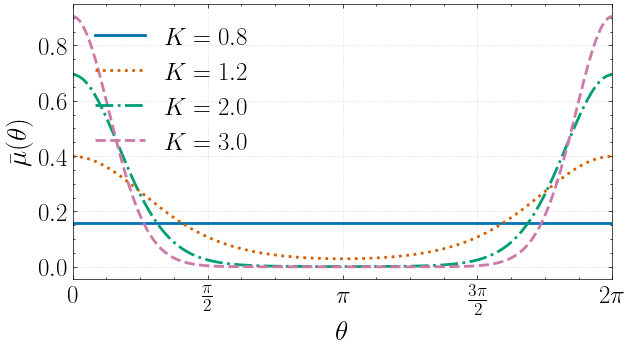

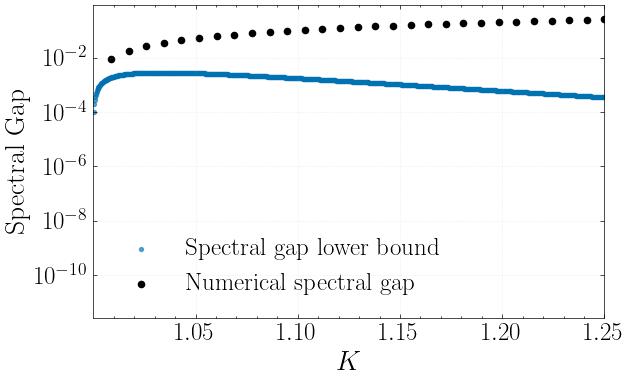

In [9]:
# Plot
fig, ax = plt.subplots(figsize=(6.5, 3.7))

for K, color, label, ls in zip(Ks, colors, labels, linestyles):
    r = compute_r(K)
    q_vals = np.exp(2*K*r*np.cos(theta))
    den, _ = quad(lambda phi: np.exp(2*K*r*np.cos(phi)), 0, 2*np.pi)
    q_vals /= den
    ax.plot(theta, q_vals, color=color, linewidth=2, label=label, ls=ls)

# Labels and layout
ax.set_xlabel(r"$\theta$", fontsize=20)
ax.set_ylabel(r"$\bar \mu(\theta)$", fontsize=20)
#ax.set_title(r"Stationary Density $\bar q(\theta)$ for Various Couplings $K$", fontsize=14)
ax.set_xlim([0, 2*np.pi])
ax.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
ax.set_xticklabels([r"$0$", r"$\frac{\pi}{2}$", r"$\pi$", r"$\frac{3\pi}{2}$", r"$2\pi$"])
ax.tick_params(axis='both', labelsize=18)
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(fontsize=18, loc="upper left")
plt.tight_layout()

# Save if needed:
plt.savefig('../images/steady_state_distributions.pdf', bbox_inches='tight')
plt.show()

# Create figure
fig, ax = plt.subplots(figsize=(6.5, 4))

# Plot all spectral values (e.g., all eigenvalues)
ax.scatter(K_values, spectral_values, s=8, alpha=0.6, color='#0072B2', label='Spectral gap lower bound')

# Highlight spectral gap values (e.g., smallest nonzero eigenvalue)
ax.scatter(np.linspace(1, 1.25, 30)[1:], spectral_gap_values[1:], s=20, color='black', label='Numerical spectral gap')
# Axis limits and scaling
ax.set_xlim(1.0001, 1.25)
ax.set_yscale('log')

# Labels and title
ax.set_xlabel('$K$', fontsize=20)
ax.set_ylabel('Spectral Gap', fontsize=20)

# Grid and legend
ax.grid(True, alpha=0.3, linestyle=':')
ax.legend(fontsize=18)

# Tick formatting
ax.tick_params(axis='both', labelsize=18)

# Tight layout and export
plt.tight_layout()
plt.savefig('../images/kuramoto_example_spectral_gap_comparison.pdf', format='PDF', bbox_inches='tight')
plt.show()

In [10]:
V = lambda x: np.zeros_like(x)
W1 = lambda x: -0.95 * np.cos(x)  # K = 0.95 (stable uniform)
W2 = lambda x: -5.0  * np.cos(x)  # K = 5.0  (unstable uniform)

alpha1 = lambda x: np.sin(x)
alpha2 = lambda x: np.cos(x)
alpha3 = lambda x: np.sin(2*x)
alpha4 = lambda x: np.cos(2*x)
grad_alpha1 = lambda x: np.cos(x)
grad_alpha2 = lambda x: -np.sin(x)
grad_alpha3 = lambda x: 2*np.cos(2*x)
grad_alpha4 = lambda x: -2*np.sin(2*x)

# Initial condition mixture
mu_0_mixed = lambda x: 0.5*(1 + 0.1*np.cos(x)) / (2*np.pi)

# Build solvers
solver1 = McKeanVlasovSolver(
    L=20, d=2*np.pi, V=V, W=W1, mu_0=mu_0_mixed, delta=1,
    alpha=[alpha1, alpha2, alpha3, alpha4],
    grad_alpha=[grad_alpha1, grad_alpha2, grad_alpha3, grad_alpha4],
    state_weight=1000, sigma=0.5
)
solver2 = McKeanVlasovSolver(
    L=20, d=2*np.pi, V=V, W=W2, mu_0=mu_0_mixed, delta=1,
    alpha=[alpha1, alpha2, alpha3, alpha4],
    grad_alpha=[grad_alpha1, grad_alpha2, grad_alpha3, grad_alpha4],
    state_weight=1000, sigma=0.5
)

# Time grid
t_span = (0, 5)
t_eval = np.linspace(0, 5, 500)

# 1) Acceleration to stable uniform (K=0.95)
sol1_c = solver1.solve_control_problem(t_span=t_span, t_eval=t_eval)
Pi1 = solver1.Pi
sol1_u = solver1.nonlinear_uncontrolled_solver_y(t_span=t_span, t_eval=t_eval)

# 2) Stabilization of unstable uniform (K=5)
sol2_c = solver2.solve_control_problem(t_span=t_span, t_eval=t_eval)
Pi2 = solver2.Pi
sol2_u = solver2.nonlinear_uncontrolled_solver_y(t_span=t_span, t_eval=t_eval)

# 3) Steering with mis-specified linearizer (K=5, frechet_flag=False)
sol3_c = solver2.solve_control_problem(t_span=t_span, t_eval=t_eval, frechet_flag=False)
Pi3 = solver2.Pi
sol3_u = solver2.nonlinear_uncontrolled_solver_y(t_span=t_span, t_eval=t_eval)

MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Riccati equation solved in 0.10 seconds.
MESSAGE - Nonlinear equation solved in 0.36 seconds.
MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Riccati equation solved in 0.04 seconds.
MESSAGE - Nonlinear equation solved in 0.31 seconds.
MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Riccati equation solved in 0.10 seconds.
MESSAGE - Nonlinear equation solved in 0.39 seconds.


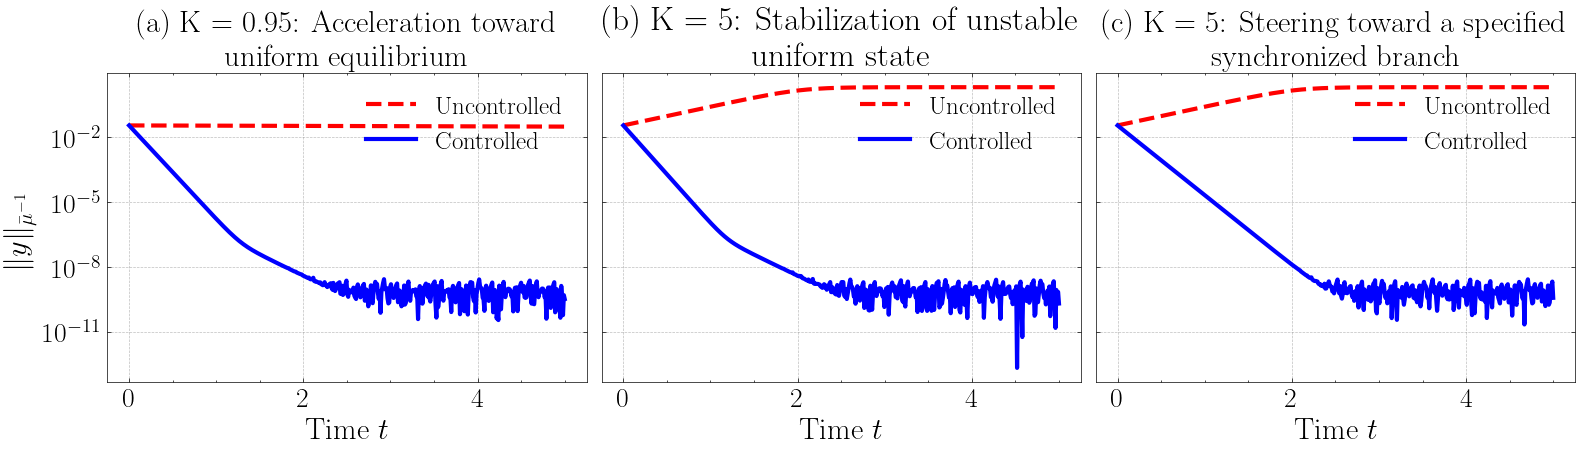

In [11]:
# Extract norms
t1 = sol1_c.t
y1_c = solver1.weighted_L2_norm(sol1_c.y)
y1_u = solver1.weighted_L2_norm(sol1_u.y)

t2 = sol2_c.t
y2_c = solver2.weighted_L2_norm(sol2_c.y)
y2_u = solver2.weighted_L2_norm(sol2_u.y)

t3 = sol3_c.t
y3_c = solver2.weighted_L2_norm(sol3_c.y)
y3_u = solver2.weighted_L2_norm(sol3_u.y)

def fit_exp(t, y):
    mask = (t>0.2)&(t<2.0)
    m, b = np.polyfit(t[mask], np.log10(y[mask]), 1)
    return m, b

m1, b1 = fit_exp(t1, y1_c)
m2, b2 = fit_exp(t2, y2_c)
m3, b3 = fit_exp(t3, y3_c)

# Plot panels
fig, axes = plt.subplots(1, 3, figsize=(16, 4.7), sharey=True)

# Panel 1: Acceleration to uniform (K=0.95)
ax = axes[0]
ax.plot(t1, y1_u, 'r--', label='Uncontrolled', lw=3)
ax.plot(t1, y1_c, 'b-',  label='Controlled', lw=3)
ax.set_yscale('log')
ax.set_title('(a) K = 0.95: Acceleration toward \n uniform equilibrium', fontsize=22)
ax.set_xlabel(r'Time $t$', fontsize=22)
ax.set_ylabel(r'$\|y\|_{\bar\mu^{-1}}$', fontsize=22)
ax.tick_params(axis='both', which='major', labelsize=20)
ax.legend(fontsize=18, loc='upper right')
ax.grid(ls='--', color='gray', alpha=0.5)

# Panel 2: Stabilize unstable uniform (K=5)
ax = axes[1]
ax.plot(t2, y2_u, 'r--', label='Uncontrolled', lw=3)
ax.plot(t2, y2_c, 'b-',  label='Controlled', lw=3)
ax.set_yscale('log')
ax.set_title('(b) K = 5: Stabilization of unstable \n uniform state', fontsize=24)
ax.set_xlabel(r'Time $t$', fontsize=22)
ax.tick_params(axis='both', which='major', labelsize=20)
ax.legend(fontsize=18, loc='upper right')
ax.grid(ls='--', color='gray', alpha=0.5)

# Panel 3: Steering with wrong linearizer (K=5)
ax = axes[2]
ax.plot(t3, y3_u, 'r--', label='Uncontrolled', lw=3)
ax.plot(t3, y3_c, 'b-',  label='Controlled', lw=3)
ax.set_yscale('log')
ax.set_title('(c) K = 5: Steering toward a specified \n synchronized branch', fontsize=22)
ax.set_xlabel(r'Time $t$', fontsize=22)
ax.tick_params(axis='both', which='major', labelsize=20)
ax.legend(fontsize=18, loc='upper right')
ax.grid(ls='--', color='gray', alpha=0.5)

plt.tight_layout()
plt.savefig('../images/kuramoto_control_panels.pdf', bbox_inches='tight')
plt.show()

In [12]:
m1, m2, m3

(np.float64(-3.49133111207259),
 np.float64(-3.4242830073062707),
 np.float64(-3.2232935842287893))

In [13]:
fit_exp(t1, y1_u)

(np.float64(-0.0108949399608844), np.float64(-1.4516320122695003))

MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Riccati equation solved in 0.33 seconds.
MESSAGE - Nonlinear equation solved in 1.14 seconds.


/var/folders/z4/m0p04g455vq7nnvq4r3swysh0000gp/T/ipykernel_73149/2864703737.py:101: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


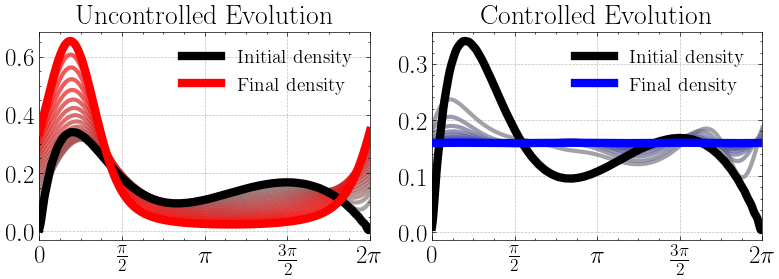

In [14]:
x = np.linspace(0, 2*np.pi, 500)

def mu_0_mixed(x, a1=4.0, b1=2.0, a2=2.0, b2=10.0):
    alpha_param1, beta_param1 = a1, b1
    Z1 = (2 * np.pi)**(alpha_param1 + beta_param1 - 1) * beta(alpha_param1, beta_param1)
    alpha_param2, beta_param2 = a2, b2
    Z2 = (2 * np.pi)**(alpha_param2 + beta_param2 - 1) * beta(alpha_param2, beta_param2)

    result = 0.5*(x**(alpha_param1 - 1) * (2 * np.pi - x)**(beta_param1 - 1)) / Z1
    result += 0.5*(x**(alpha_param2 - 1) * (2 * np.pi - x)**(beta_param2 - 1)) / Z2
    
    return result

cmap_uncontrolled = LinearSegmentedColormap.from_list("grey_red", ["grey", "red"])
cmap_controlled   = LinearSegmentedColormap.from_list("grey_blue", ["grey", "blue"])

V = lambda x: np.zeros_like(x)
W2 = lambda x: -5*np.cos(x)

alpha1 = lambda x: np.sin(x)
alpha2 = lambda x: np.cos(x)
alpha3 = lambda x: np.sin(2*x)
alpha4 = lambda x: np.cos(2*x)

nabla_alpha1 = lambda x: np.cos(x)
nabla_alpha2 = lambda x: -np.sin(x)
nabla_alpha3 = lambda x: 2 * np.cos(2*x)
nabla_alpha4 = lambda x: -2 * np.sin(2*x)

solver2 = McKeanVlasovSolver(L=50, d=2*np.pi, V=V, alpha=[alpha1, alpha2, alpha3, alpha4], 
                            W=W2, mu_0=mu_0_mixed, min_fourier_samples=2000, delta=0.0001, 
                            grad_alpha=[nabla_alpha1, nabla_alpha2, nabla_alpha3, nabla_alpha4], 
                            state_weight=1000, sigma=0.5)

t_max = 1
num_snapshots = 20
t_eval = np.linspace(0, t_max, num_snapshots)
solution2_c = solver2.solve_control_problem(t_span=(0, t_max), t_eval=t_eval)
solution2_u = solver2.nonlinear_uncontrolled_solver_y(t_span=(0, t_max), t_eval=t_eval)
# Custom colormaps (grey→red and grey→blue)
cmap_uncontrolled = LinearSegmentedColormap.from_list("grey_red",  ["grey","red"])
cmap_controlled   = LinearSegmentedColormap.from_list("grey_blue", ["grey","blue"])

# Plot parameters
num_snapshots    = len(solution2_u.t)
lw_primary       = 6    # linewidth for first & last snapshot
lw_secondary     = 3    # linewidth for intermediates
alpha_secondary  = 0.7  # alpha for intermediate curves

# Create 1×2 figure
fig, axes = plt.subplots(1, 2, figsize=(8, 3), constrained_layout=True)

# Panel 1: Uncontrolled Evolution
ax = axes[0]
for i in range(num_snapshots):
    y_vals = solver2.reconstruction(solution2_u.y[:, i] + solver2.bar_mu_k, x)
    if i == 0:
        ax.plot(x, y_vals, color='black', linewidth=lw_primary,
                label='Initial density', zorder=3)
    elif i == num_snapshots - 1:
        ax.plot(x, y_vals, color='red', linewidth=lw_primary,
                label='Final density', zorder=3)
    else:
        frac = i/(num_snapshots - 1)
        ax.plot(x, y_vals, color=cmap_uncontrolled(frac),
                linewidth=lw_secondary, alpha=alpha_secondary, zorder=1)

ax.set_xlim([0, 2*np.pi])
ax.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
ax.set_xticklabels([r"$0$", r"$\frac{\pi}{2}$", r"$\pi$", r"$\frac{3\pi}{2}$", r"$2\pi$"])
ax.tick_params(axis='both', labelsize=18)

ax.set_title('Uncontrolled Evolution', fontsize=20)
ax.legend(loc='upper right', fontsize=14)
ax.grid(ls='--', color='gray', alpha=0.5)

# Panel 2: Controlled Evolution
ax = axes[1]
for i in range(num_snapshots):
    y_vals = solver2.reconstruction(solution2_c.y[:, i] + solver2.bar_mu_k, x)
    if i == 0:
        ax.plot(x, y_vals, color='black', linewidth=lw_primary,
                label='Initial density', zorder=3)
    elif i == num_snapshots - 1:
        ax.plot(x, y_vals, color='blue', linewidth=lw_primary,
                label='Final density', zorder=3)
    else:
        frac = i/(num_snapshots - 1)
        ax.plot(x, y_vals, color=cmap_controlled(frac),
                linewidth=lw_secondary, alpha=alpha_secondary, zorder=1)

ax.set_xlim([0, 2*np.pi])
ax.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
ax.set_xticklabels([r"$0$", r"$\frac{\pi}{2}$", r"$\pi$", r"$\frac{3\pi}{2}$", r"$2\pi$"])
ax.tick_params(axis='both', labelsize=18)

ax.set_title('Controlled Evolution', fontsize=20)
ax.legend(loc='upper right', fontsize=14)
ax.grid(ls='--', color='gray', alpha=0.5)

fig.tight_layout()
plt.savefig('../images/kuramoto_example_stabilization.pdf', bbox_inches='tight')
plt.show()

MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Riccati equation solved in 0.05 seconds.
MESSAGE - Nonlinear equation solved in 0.82 seconds.
MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Riccati equation solved in 0.04 seconds.
MESSAGE - Nonlinear equation solved in 0.92 seconds.
MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Riccati equation solved in 0.04 seconds.
MESSAGE - Nonlinear equation solved in 0.93 seconds.
MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Riccati equation solved in 0.07 seconds.
MESSAGE - Nonlinear equation solved in 0.89 seconds.
MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Riccati equation solved in 0.04 seconds.
MESSAGE - Nonlinear equation solved in 0.94 seconds.
MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAG

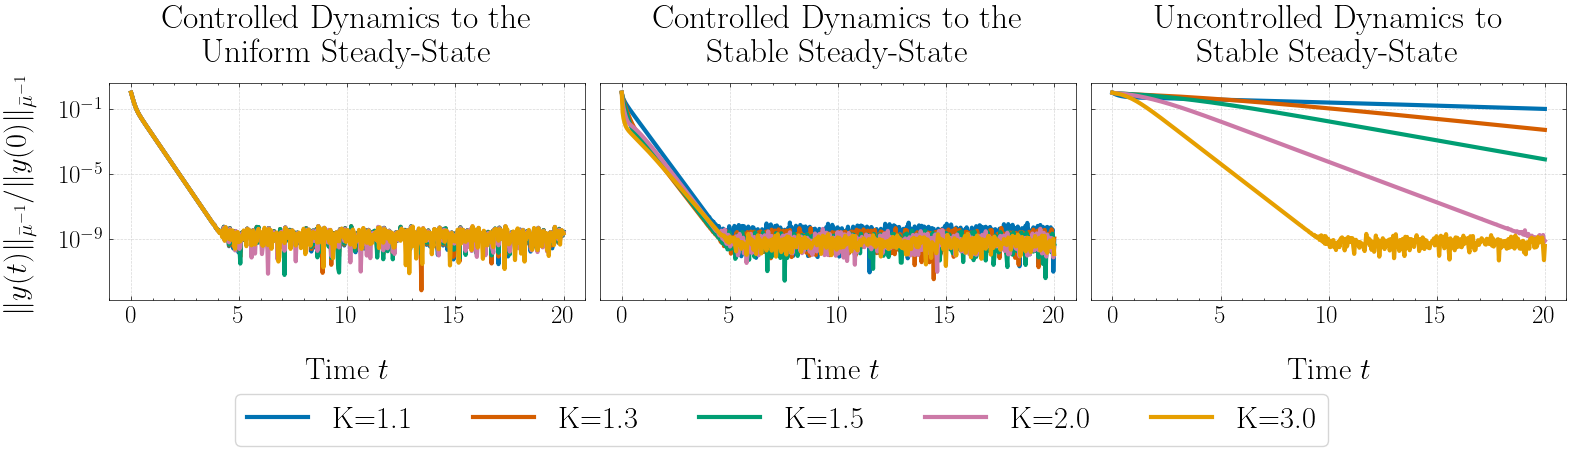

In [15]:
plt.rcParams.update({
    'axes.titlesize': 24,
    'axes.labelsize': 22,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'legend.fontsize': 22
})
fig, axes = plt.subplots(1, 3, figsize=(16, 4.1), sharex=True, sharey='row')

# Colorblind-friendly palette
colors = [
    "#0072B2",  # blue
    "#D55E00",  # vermillion
    "#009E73",  # green
    "#CC79A7",  # purple
    "#E69F00",  # orange
]

K_values = [1.1, 1.3, 1.5, 2.0, 3.0]
initial_distribution = lambda x: mu_0_mixed(x, a1=2.0, b1=2.0, a2=2.0, b2=2.0)

for index, K in enumerate(K_values):

    # Control to the uniform distribution
    solver1 = McKeanVlasovSolver(L=20, d=2*np.pi, V=V, alpha=[alpha1, alpha2, alpha3, alpha4], 
                                W=lambda x: -K*np.cos(x), mu_0=initial_distribution, min_fourier_samples=2000, delta=3, 
                                grad_alpha=[nabla_alpha1, nabla_alpha2, nabla_alpha3, nabla_alpha4], 
                                state_weight=1000, sigma=0.5)

    # Control to the stable distribution
    a = solver1.fourier.project_function(func=desired_distribution(K))
    
    solver2 = McKeanVlasovSolver(L=20, d=2*np.pi, V=V, alpha=[alpha1, alpha2, alpha3, alpha4], 
                                W=lambda x: -K*np.cos(x), mu_0=initial_distribution, min_fourier_samples=2000, delta=3, 
                                grad_alpha=[nabla_alpha1, nabla_alpha2, nabla_alpha3, nabla_alpha4], 
                                state_weight=1000, sigma=0.5, 
                                final_distribution=a)

    solution1 = solver1.solve_control_problem(t_span=(0, 20.0), t_eval=np.linspace(0, 20.0, 500))
    solution_uncontrolled1 = solver1.nonlinear_uncontrolled_solver_y(t_span=(0, 20.0), t_eval=np.linspace(0, 20.0, 500))

    solution2 = solver2.solve_control_problem(t_span=(0, 20.0), t_eval=np.linspace(0, 20.0, 500))
    solution_uncontrolled2 = solver2.nonlinear_uncontrolled_solver_y(t_span=(0, 20.0), t_eval=np.linspace(0, 20.0, 500))

    y_norm1 = solver1.weighted_L2_norm(solution1.y) 
    y_norm1 /= y_norm1[0]
    y_norm_uncontrolled1 = solver1.weighted_L2_norm(solution_uncontrolled1.y)
    y_norm_uncontrolled1 /= y_norm_uncontrolled1[0]

    y_norm2 = solver2.weighted_L2_norm(solution2.y)
    y_norm2 /= y_norm2[0]
    y_norm_uncontrolled2 = solver2.weighted_L2_norm(solution_uncontrolled2.y)
    y_norm_uncontrolled2 /= y_norm_uncontrolled2[0]

    t_points = solution1.t
    # Plot controlled to uniform
    axes[0].plot(t_points, y_norm1, label=f"K={K}", color=colors[index], lw=3)
    # Plot uncontrolled to uniform
    #axes[0, 1].plot(t_points, y_norm_uncontrolled1, label=r"$K={}$".format(K), color=colors[index], lw=3)
    # Plot controlled to stable
    axes[1].plot(t_points, y_norm2, label=f"K={K}", color=colors[index], lw=3)
    # Plot uncontrolled to stable
    axes[2].plot(t_points, y_norm_uncontrolled2, label=r"$K={}$".format(K), color=colors[index], lw=3)

# Axis labels and titles
for ax in axes.flat:
    ax.set_yscale('log')
    ax.grid(True, linestyle='--', alpha=0.5)

axes[0].set_title('Controlled Dynamics to the \n Uniform Steady‐State', pad=15)
#axes[0, 1].set_title('Uncontrolled dynamics → Uniform steady‐state', pad=15)
axes[1].set_title('Controlled Dynamics to the \n Stable Steady‐State', pad=15)
axes[2].set_title('Uncontrolled Dynamics to \n Stable Steady‐State', pad=15)

axes[0].set_xlabel('Time $t$', labelpad=22)
axes[1].set_xlabel('Time $t$', labelpad=22)
axes[2].set_xlabel('Time $t$', labelpad=22)
axes[0].set_ylabel(r'$\|y(t)\|_{\bar\mu^{-1}} / \|y(0)\|_{\bar\mu^{-1}}$', labelpad=16)
#axes[1, 0].set_ylabel(r'$\|y(t)\|_{\bar\mu^{-1}} / \|y(0)\|_{\bar\mu^{-1}}$', labelpad=16)

# Legend only once
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc='lower center',
    ncol=len(labels),      # one column per entry
    frameon=True,         # turn off legend box if you like
    bbox_to_anchor=(0.5, -0.15),  # slightly below the subplots
    fontsize=22
)
plt.subplots_adjust(bottom=0.1)

plt.tight_layout()
plt.savefig("../images/kuramoto_example_changing_K.pdf", bbox_inches="tight")
plt.show()

In [69]:
V = lambda x: np.zeros_like(x)
W = lambda K: lambda x: -K*np.cos(x)

alpha1 = lambda x: np.sin(x)
alpha2 = lambda x: np.cos(x)
alpha3 = lambda x: np.sin(2*x)
alpha4 = lambda x: np.cos(2*x)

nabla_alpha1 = lambda x: np.cos(x)
nabla_alpha2 = lambda x: -np.sin(x)
nabla_alpha3 = lambda x: 2 * np.cos(2*x)
nabla_alpha4 = lambda x: -2 * np.sin(2*x)

mask = solver.k_vals != 0
K_values = [0.5, 0.95, 5]

MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.


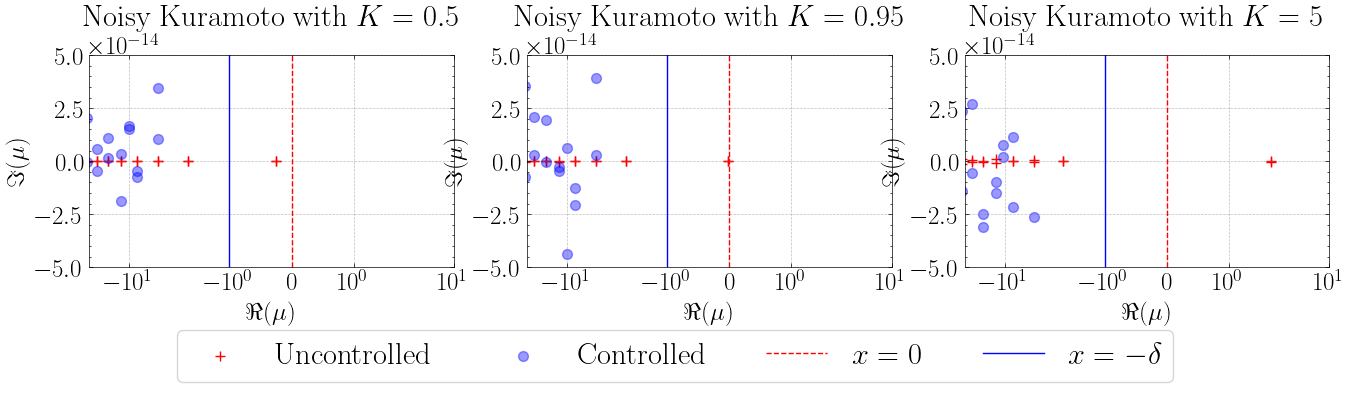

In [88]:
fig, ax = plt.subplots(1, 3, figsize=(16,4))

for index, K in enumerate(K_values):

    solver = McKeanVlasovSolver(L=50, d=2*np.pi, V=V, alpha=[alpha1, alpha2, alpha3, alpha4], 
                                W=W(K=K), mu_0=mu_0_mixed, min_fourier_samples=2000, delta=1, 
                                grad_alpha=[nabla_alpha1, nabla_alpha2, nabla_alpha3, nabla_alpha4], 
                                state_weight=1000, sigma=0.5)
    solver.solve_riccati()

    A = -(solver.L_V + solver.sigma * solver.D + solver.K)[mask][:, mask]
    Pi = solver.Pi[mask][:, mask]
    B = solver.B[mask]

    eig_uncontrolled = np.linalg.eigvals(A)
    eig_controlled = np.linalg.eigvals(A - B@np.conj(B).T@Pi)

    sc1 = ax[index].scatter(np.real(eig_uncontrolled), np.imag(eig_uncontrolled), c='r', marker='+', s=50, label='Uncontrolled')
    sc2 = ax[index].scatter(np.real(eig_controlled), np.imag(eig_controlled), c='b', marker='o', alpha=0.4, s=50, label='Controlled')
    ax[index].set_xscale('symlog', linthresh=1.5, linscale=1, base=10)
    ax[index].set_xlim((-30,10))
    ax[index].set_ylim((-0.5e-13, 0.5e-13))
    ax[index].set_xlabel(r"$\Re(\mu)$", fontsize=18)
    ax[index].set_ylabel(r"$\Im(\mu)$", fontsize=18)
    ax[index].grid(ls="--", c='gray', alpha=0.5)
    ax[index].set_title(r"Noisy Kuramoto with $K={}$".format(K), fontsize=22)
    sc3 = ax[index].axvline(0.0, color='red', ls='--', label=r'$x=0$')
    sc4 = ax[index].axvline(-solver.delta, color='blue', ls='-', label=r'$x=-\delta$')

fig.legend(handles=[sc1, sc2, sc3, sc4], loc='lower center', ncol=4, fontsize=22, frameon=True)
fig.subplots_adjust(bottom=0.35)

plt.savefig('../images/kuramoto_spectra.pdf', bbox_inches='tight')    
plt.show()

# Example 2

TypeError: __init__() got an unexpected keyword argument 'G'

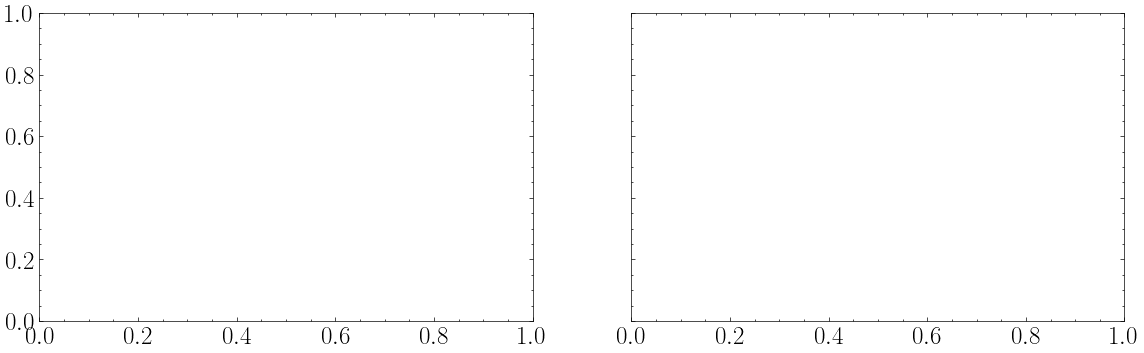

In [16]:
# --- Define potentials, shape functions, and gradients ---
G = lambda x: np.cos(2 * x)
W = lambda x: -np.cos(x)

alpha = [lambda x: np.sin(x),
         lambda x: np.cos(x),
         lambda x: np.sin(2*x),
         lambda x: np.cos(2*x)]
grad_alpha = [lambda x: np.cos(x),
              lambda x: -np.sin(x),
              lambda x: 2*np.cos(2*x),
              lambda x: -2*np.sin(2*x)]

# Common solver settings
common_kwargs = dict(
    L=20, d=2*np.pi, G=G, W=W, mu_0=mu_0_mixed,
    min_fourier_samples=2000, delta=-1e-3, alpha=alpha,
    grad_alpha=grad_alpha, state_weight=1e5
)

# Colorblind-safe palette
colors = ["#0072B2", "#D55E00", "#009E73", "#CC79A7", "#E69F00"]

# --- First figure: varying sigma across bifurcation ---
sigma_vals1 = [0.77, 0.79, 0.81, 0.83, 0.85]
t_max = 50
t_eval = np.linspace(0, t_max, 1000)

fig, ax = plt.subplots(1, 2, figsize=(14, 4), sharex=True, sharey=True)
for i, sigma in enumerate(sigma_vals1):
    solver = McKeanVlasovSolver(**common_kwargs, sigma=sigma)
    sol_c = solver.solve_control_problem(t_span=(0, t_max), t_eval=t_eval)
    sol_u = solver.nonlinear_uncontrolled_solver_y(t_span=(0, t_max), t_eval=t_eval)
    y_c = np.linalg.norm(sol_c.y, axis=0)
    y_u = np.linalg.norm(sol_u.y, axis=0)
    ax[0].plot(sol_c.t, y_c, color=colors[i], lw=3, label=f"$\\sigma={sigma}$")
    ax[1].plot(sol_u.t, y_u, color=colors[i], lw=3, label=f"$\\sigma={sigma}$")

for axis in ax:
    axis.set_yscale('log')
    axis.grid(ls='--', color='grey', alpha=0.7)
    axis.set_xlabel('Time $t$', fontsize=16)
ax[0].set_ylabel(r'$\|y(\cdot,t)\|_{L^2}$', fontsize=16)
ax[0].set_title('Controlled dynamics', fontsize=18)
ax[1].set_title('Uncontrolled dynamics', fontsize=18)
ax[0].legend(loc='upper right', fontsize=16)
ax[1].legend(loc='upper right', fontsize=16)
plt.tight_layout()
plt.show()

# --- Second figure: lower sigmas ---
sigma_vals2 = [0.5, 0.6, 0.7, 0.75]
fig, ax = plt.subplots(1, 2, figsize=(14, 4), sharex=True, sharey=True)
for i, sigma in enumerate(sigma_vals2):
    # compute steady state projection
    solver_tmp = McKeanVlasovSolver(**common_kwargs, sigma=sigma)
    C = solver_tmp.fourier.integrate(lambda x: np.exp(-np.cos(2*x)/sigma), n_points=2000)
    bar_mu = solver_tmp.fourier.project_function(lambda x: np.exp(-np.cos(2*x)/sigma)/C)
    
    solver = McKeanVlasovSolver(**common_kwargs, sigma=sigma, final_distribution=bar_mu)
    sol_c = solver.solve_control_problem(t_span=(0, t_max), t_eval=t_eval)
    sol_u = solver.nonlinear_uncontrolled_solver_y(t_span=(0, t_max), t_eval=t_eval)
    
    y_c = np.linalg.norm(sol_c.y, axis=0)
    y_u = np.linalg.norm(sol_u.y, axis=0)
    ax[0].plot(sol_c.t, y_c, color=colors[i], lw=3, label=f"$\\sigma={sigma}$")
    ax[1].plot(sol_u.t, y_u, color=colors[i], lw=3, label=f"$\\sigma={sigma}$")

for axis in ax:
    axis.set_yscale('log')
    axis.grid(ls='--', color='grey', alpha=0.7)
    axis.set_xlabel('Time $t$', fontsize=16)
ax[0].set_ylabel(r'$\|y(\cdot,t)\|_{L^2}$', fontsize=16)
ax[0].set_title('Controlled to $\\bar\\mu$', fontsize=18)
ax[1].set_title('Uncontrolled to $\\bar\\mu$', fontsize=18)
ax[0].legend(loc='upper right', fontsize=12)
ax[1].legend(loc='upper right', fontsize=12)
plt.tight_layout()
plt.show()

In [43]:
V = lambda x: np.cos(2 * x)
W = lambda x: -np.cos(x)

alpha = [lambda x: np.sin(x),
         lambda x: np.cos(x),
         lambda x: np.sin(2*x),
         lambda x: np.cos(2*x)]
grad_alpha = [lambda x: np.cos(x),
              lambda x: -np.sin(x),
              lambda x: 2*np.cos(2*x),
              lambda x: -2*np.sin(2*x)]

# Common solver kwargs
common_kwargs = dict(
    L=20, d=2*np.pi, V=V, W=W, mu_0=mu_0_mixed,
    min_fourier_samples=2000, delta=1,
    alpha=alpha, grad_alpha=grad_alpha,
    state_weight=1e5
)

# Sweep parameters
sigma_values = np.linspace(0.6, 1.0, 21)
t_max = 50
t_eval = np.linspace(0, t_max, 200)

# Preallocate norm matrices
norm_control = np.zeros((len(sigma_values), len(t_eval)))
norm_uncontrol = np.zeros((len(sigma_values), len(t_eval)))

# --- Compute norms across sigma and time -----------------------
for i, sigma in enumerate(sigma_values):
    solver_tmp = McKeanVlasovSolver(**common_kwargs, sigma=sigma)
    C = solver_tmp.fourier.integrate(lambda x: np.exp(-np.cos(2*x)/sigma), n_points=2000)
    bar_mu = solver_tmp.fourier.project_function(lambda x: np.exp(-np.cos(2*x)/sigma)/C)
    
    solver = McKeanVlasovSolver(**common_kwargs, sigma=sigma, final_distribution=bar_mu)
    sol_c = solver.solve_control_problem(t_span=(0, t_max), t_eval=t_eval)
    sol_u = solver.nonlinear_uncontrolled_solver_y(t_span=(0, t_max), t_eval=t_eval)
    norm_control[i, :] = solver.weighted_L2_norm(sol_c.y)
    norm_uncontrol[i, :] = solver.weighted_L2_norm(sol_u.y)

MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Riccati equation solved in 0.04 seconds.
MESSAGE - Nonlinear equation solved in 5.14 seconds.
MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Riccati equation solved in 0.01 seconds.
MESSAGE - Nonlinear equation solved in 4.90 seconds.
MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Riccati equation solved in 0.01 seconds.
MESSAGE - Nonlinear equation solved in 4.31 seconds.
MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Riccati equation solved in 0.01 seconds.
MESSAGE - Nonlinear equation solved in 4.65 seconds.
MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Riccati equation solved in 0.01 seconds.
MESSAGE - Nonlinear equation solved in 4.03 seconds.
MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAG

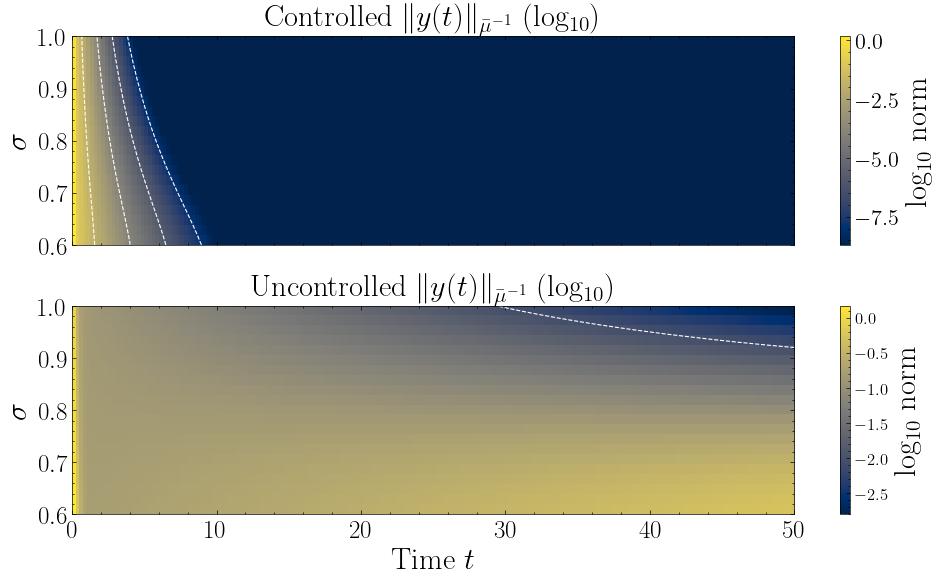

In [52]:
# --- Plot heatmaps ----------------------------------------------
fig, axs = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# compute log10 and clip tiny noise
logC = np.log10(np.clip(norm_control, 2e-9, None))
logU = np.log10(np.clip(norm_uncontrol, 2e-9, None))

# build mesh for contour
T, S = np.meshgrid(np.linspace(0, t_max, logC.shape[1]), sigma_values)

# Controlled heatmap
im0 = axs[0].imshow(
    logC,
    aspect='auto',
    origin='lower',
    extent=[0, t_max, sigma_values[0], sigma_values[-1]],
    cmap='cividis'
)
# now levels in increasing order
axs[0].contour(
    T, S, logC,
    levels=[-8, -6, -4, -2], colors='white', linewidths=0.8
)
axs[0].set_ylabel(r'$\sigma$', fontsize=22)
axs[0].set_title(r'Controlled $\|y(t)\|_{\bar\mu^{-1}}$ (log$_{10}$)', fontsize=22)
cbar0 = fig.colorbar(im0, ax=axs[0], orientation='vertical', label='log$_{10}$ norm')
cbar0.ax.tick_params(labelsize=16)

# Uncontrolled heatmap
im1 = axs[1].imshow(
    logU,
    aspect='auto',
    origin='lower',
    extent=[0, t_max, sigma_values[0], sigma_values[-1]],
    cmap='cividis'
)
axs[1].contour(
    T, S, logU,
    levels=[-8, -6, -4, -2], colors='white', linewidths=0.8
)
axs[1].set_xlabel('Time $t$', fontsize=22)
axs[1].set_ylabel(r'$\sigma$', fontsize=22)
axs[1].set_title(r'Uncontrolled $\|y(t)\|_{\bar\mu^{-1}}$ (log$_{10}$)', fontsize=22)
cbar1 = fig.colorbar(im1, ax=axs[1], orientation='vertical', label='log$_{10}$ norm')
cbar1.ax.tick_params(labelsize=12)

plt.tight_layout()
plt.savefig('../images/kuramoto_potential_control_heatmap.pdf', bbox_inches='tight')
plt.show()

MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Riccati equation solved in 0.00 seconds.
MESSAGE - Nonlinear equation solved in 89.44 seconds.
MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Riccati equation solved in 0.00 seconds.
MESSAGE - Nonlinear equation solved in 82.73 seconds.
MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Riccati equation solved in 0.01 seconds.
MESSAGE - Nonlinear equation solved in 70.41 seconds.
MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Riccati equation solved in 0.00 seconds.
MESSAGE - Nonlinear equation solved in 56.06 seconds.


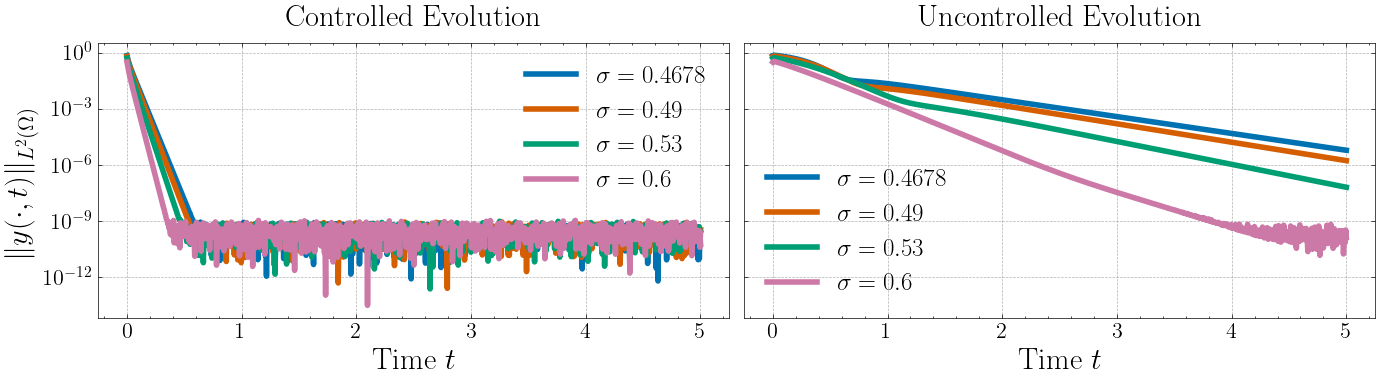

In [6]:
# --- Define model parameters ---------------------------------------------
eta = 0.05
V = lambda x: -eta * np.cos(2 * np.pi * x)
W = lambda x: -np.cos(2 * np.pi * x)
sigma_values = [0.4678, 0.49, 0.53, 0.6]
d = 1
t_max = 5
t_eval = np.linspace(0, t_max, 1000)

alpha = [lambda x: np.sin(x),
         lambda x: np.cos(x),
         lambda x: np.sin(2*x),
         lambda x: np.cos(2*x)]
grad_alpha = [lambda x: np.cos(x),
              lambda x: -np.sin(x),
              lambda x: 2*np.cos(2*x),
              lambda x: -2*np.sin(2*x)]

common_kwargs = dict(
    L=10, d=d, V=V, W=W, mu_0=mu_0_mixed,
    min_fourier_samples=2000, delta=1,
    alpha=alpha, grad_alpha=grad_alpha,
    state_weight=1e5
)


# Colorblind-safe palette
colors = ["#0072B2", "#D55E00", "#009E73", "#CC79A7"]

# --- Plotting -------------------------------------------------------------
plt.rcParams.update({
    'axes.titlesize': 22,
    'axes.labelsize': 20,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 18
})

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharex=True, sharey=True)

for idx, sigma in enumerate(sigma_values):
    solver = McKeanVlasovSolver(**common_kwargs, sigma=sigma)
    
    sol_c = solver.solve_control_problem(t_span=(0, t_max), t_eval=t_eval)
    sol_u = solver.nonlinear_uncontrolled_solver_y(t_span=(0, t_max), t_eval=t_eval)
    
    y_c = solver.weighted_L2_norm(sol_c.y)
    y_u = solver.weighted_L2_norm(sol_u.y)
    
    axes[0].plot(sol_c.t, y_c, color=colors[idx], lw=4, label=f"$\\sigma={sigma}$")
    axes[1].plot(sol_u.t, y_u, color=colors[idx], lw=4, label=f"$\\sigma={sigma}$")

for ax in axes:
    ax.set_yscale('log')
    ax.grid(True, linestyle='--', color='grey', alpha=0.6)
    ax.set_xlabel("Time $t$", fontsize=22)

axes[0].set_ylabel(r"$\|y(\cdot,t)\|_{\bar\mu^{-1}}$", fontsize=22)
axes[0].set_title("Controlled Evolution", pad=12)
axes[1].set_title("Uncontrolled Evolution", pad=12)

axes[0].legend(loc='upper right')
axes[1].legend(loc='lower left')

plt.tight_layout()
plt.savefig("../images/o2_example_control_different_sigmas.pdf", bbox_inches='tight')
plt.show()

In [8]:
# --- Define model parameters ---------------------------------------------
eta = 0.05
V = lambda x: -eta * np.cos(2 * np.pi * x)
W = lambda x: -np.cos(2 * np.pi * x)
sigma_values = [0.4678, 0.49, 0.53, 0.6]
d = 1
t_max = 5
t_eval = np.linspace(0, t_max, 1000)

alpha = [lambda x: np.sin(x),
         lambda x: np.cos(x),
         lambda x: np.sin(2*x),
         lambda x: np.cos(2*x)]
grad_alpha = [lambda x: np.cos(x),
              lambda x: -np.sin(x),
              lambda x: 2*np.cos(2*x),
              lambda x: -2*np.sin(2*x)]

common_kwargs = dict(
    L=10, d=d, V=V, W=W, mu_0=mu_0_mixed,
    min_fourier_samples=2000, delta=1,
    alpha=alpha, grad_alpha=grad_alpha,
    state_weight=1e5
)

experiments = []

for idx, sigma in enumerate(sigma_values):
    solver = McKeanVlasovSolver(**common_kwargs, sigma=sigma)
    
    sol_c = solver.solve_control_problem(t_span=(0, t_max), t_eval=t_eval)
    sol_u = solver.nonlinear_uncontrolled_solver_y(t_span=(0, t_max), t_eval=t_eval)
    experiments.append((sol_c, sol_u))

MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Riccati equation solved in 0.00 seconds.
MESSAGE - Nonlinear equation solved in 88.48 seconds.
MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Riccati equation solved in 0.00 seconds.
MESSAGE - Nonlinear equation solved in 83.31 seconds.
MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Riccati equation solved in 0.03 seconds.
MESSAGE - Nonlinear equation solved in 71.06 seconds.
MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Riccati equation solved in 0.00 seconds.
MESSAGE - Nonlinear equation solved in 55.97 seconds.


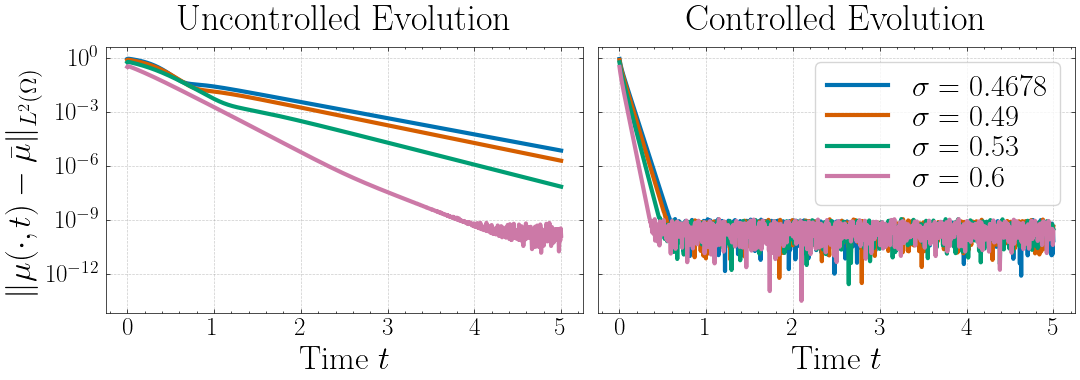

In [27]:
# Colorblind-safe palette
colors = ["#0072B2", "#D55E00", "#009E73", "#CC79A7"]

# --- Plotting -------------------------------------------------------------
plt.rcParams.update({
    'axes.titlesize': 26,
    'axes.labelsize': 24,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'legend.fontsize': 22
})

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True, sharey=True)

for idx, sigma in enumerate(sigma_values):

        
    y_c = solver.weighted_L2_norm(experiments[idx][0].y)
    y_u = solver.weighted_L2_norm(experiments[idx][1].y)
    
    axes[1].plot(experiments[idx][0].t, y_c, color=colors[idx], lw=3, label=f"$\\sigma={sigma}$")
    axes[0].plot(experiments[idx][1].t, y_u, color=colors[idx], lw=3, label=f"$\\sigma={sigma}$")

for ax in axes:
    ax.set_yscale('log')
    ax.grid(True, linestyle='--', color='grey', alpha=0.4)
    ax.set_xlabel("Time $t$", fontsize=24)

axes[0].set_ylabel(r"$\|\mu(\cdot,t) - \bar\mu\|_{L^2(\Omega)}$", fontsize=24)
axes[1].set_title("Controlled Evolution", pad=12)
axes[0].set_title("Uncontrolled Evolution", pad=12)

#axes[0].legend(loc='upper right')
axes[1].legend(loc='upper right', ncol=1, frameon=True, labelspacing=0.1)

plt.tight_layout()
plt.savefig("../images/o2_example_control_different_sigmas.pdf", bbox_inches='tight')
plt.show()

MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Riccati equation solved in 0.01 seconds.
MESSAGE - Nonlinear equation solved in 1.19 seconds.
MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Riccati equation solved in 0.01 seconds.
MESSAGE - Nonlinear equation solved in 1.19 seconds.
MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Riccati equation solved in 0.01 seconds.
MESSAGE - Nonlinear equation solved in 1.25 seconds.
MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Riccati equation solved in 0.31 seconds.
MESSAGE - Nonlinear equation solved in 3.75 seconds.


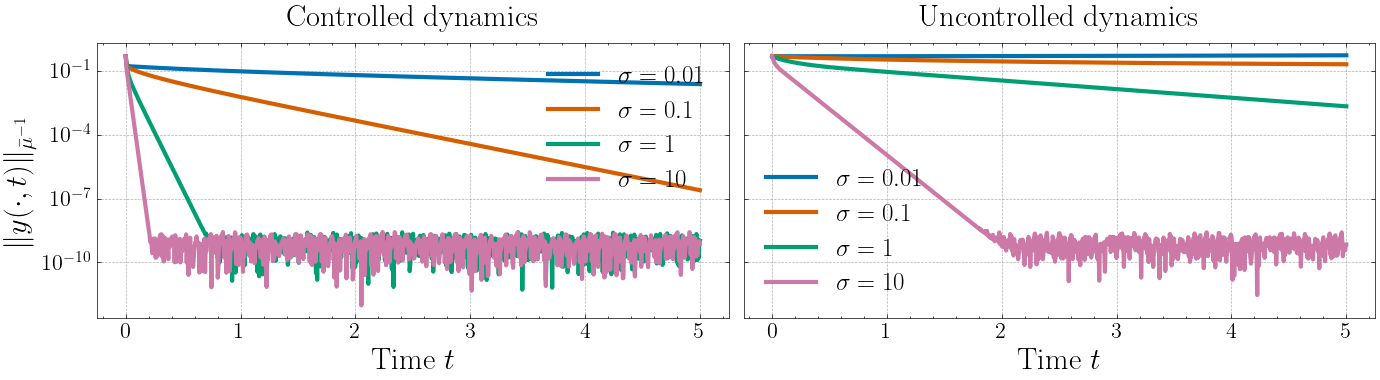

In [79]:
# --- Define model parameters ---
V = lambda x: np.zeros_like(x)
W = lambda theta: lambda x: - np.exp(theta * np.cos(x)) / (2*np.pi * bessel(0, theta))
sigma_values = [0.01, 0.1, 1, 10]
d = 2*np.pi
t_max = 5
t_eval = np.linspace(0, t_max, 1000)

alpha = [lambda x: np.sin(x),
         lambda x: np.cos(x),
         lambda x: np.sin(2*x),
         lambda x: np.cos(2*x),
         lambda x: np.sin(3*x),
         lambda x: np.cos(3*x),
         lambda x: np.sin(4*x),
         lambda x: np.cos(4*x)]
grad_alpha = [lambda x: np.cos(x),
              lambda x: -np.sin(x),
              lambda x: 2*np.cos(2*x),
              lambda x: -2*np.sin(2*x),
              lambda x: 3*np.cos(3*x),
              lambda x: -3*np.sin(3*x),
              lambda x: 4*np.cos(4*x),
              lambda x: -4*np.sin(4*x)]

common_kwargs = dict(
    L=20, d=d, V=V, W=W(theta=1), mu_0=mu_0_mixed,
    min_fourier_samples=2000, delta=0.2,
    alpha=alpha, grad_alpha=grad_alpha,
    state_weight=1e5
)

# Colorblind-safe palette
colors = ["#0072B2", "#D55E00", "#009E73", "#CC79A7"]

# --- Plotting ----
plt.rcParams.update({
    'axes.titlesize': 22,
    'axes.labelsize': 20,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 18
})

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharex=True, sharey=True)

for idx, sigma in enumerate(sigma_values):
    solver = McKeanVlasovSolver(**common_kwargs, sigma=sigma)
    
    sol_c = solver.solve_control_problem(t_span=(0, t_max), t_eval=t_eval)
    sol_u = solver.nonlinear_uncontrolled_solver_y(t_span=(0, t_max), t_eval=t_eval)
    
    y_c = solver.weighted_L2_norm(sol_c.y)
    y_u = solver.weighted_L2_norm(sol_u.y)
    
    axes[0].plot(sol_c.t, y_c, color=colors[idx], lw=3, label=f"$\\sigma={sigma}$")
    axes[1].plot(sol_u.t, y_u, color=colors[idx], lw=3, label=f"$\\sigma={sigma}$")

for ax in axes:
    ax.set_yscale('log')
    ax.grid(True, linestyle='--', color='grey', alpha=0.6)
    ax.set_xlabel("Time $t$", fontsize=22)

axes[0].set_ylabel(r"$\|y(\cdot,t)\|_{\bar\mu^{-1}}$", fontsize=22)
axes[0].set_title("Controlled dynamics", pad=12)
axes[1].set_title("Uncontrolled dynamics", pad=12)

axes[0].legend(loc='upper right')
axes[1].legend(loc='lower left')

plt.tight_layout()
plt.savefig("../images/von_mises_control_different_sigmas.pdf", bbox_inches='tight')
plt.show()

In [ ]:
# Genuine 2D attractive von Mises-type example
from generate_figures import run_von_mises_2d_example

run_von_mises_2d_example()


In [ ]:
# The 2D figure is generated by run_von_mises_2d_example() above.
